<a href="https://colab.research.google.com/github/dan1esl/A3CNN/blob/main/A3CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Etapa 1

# Pré-processamento dos dados


Import dos módulos necessários.

In [1]:
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras.utils import to_categorical
from keras.preprocessing import image
from keras.layers import BatchNormalization, LeakyReLU

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
%matplotlib inline


Carregamento do dataset de números do mnist.

In [3]:
from keras.datasets import mnist
(train_X, train_Y), (test_X, test_Y) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step



Redimensionamento das imagens.

In [4]:
train_X = train_X.reshape(-1, 28, 28, 1)
test_X = test_X.reshape(-1, 28, 28, 1)
train_X.shape, test_X.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

In [5]:
train_X = train_X.astype('float32')
test_X = test_X.astype('float32')
train_X = train_X / 255.
test_X = test_X / 255.

Visualização do Dataset

Text(0.5, 1.0, 'Imagem teste : 9')

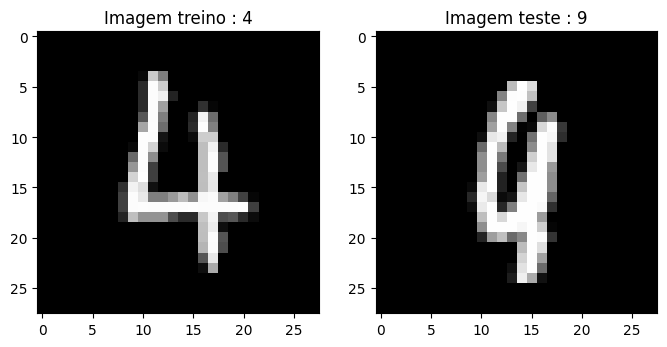

In [6]:
plt.figure(figsize=(8,8))

i=1232

plt.subplot(121)
plt.imshow(train_X[i,:,:], cmap='gray')
plt.title("Imagem treino : {}".format(train_Y[i]))

plt.subplot(122)
plt.imshow(test_X[i,:,:], cmap='gray')
plt.title("Imagem teste : {}".format(test_Y[i]))



Conversão das variáveis para one-hot.

In [7]:
train_Y_one_hot = to_categorical(train_Y)
test_Y_one_hot = to_categorical(test_Y)

print('Classificação original: ', train_Y[2222] )
print('Classificação one-hot: ', train_Y_one_hot[2222])

Classificação original:  4
Classificação one-hot:  [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]


In [8]:
train_X, valid_X, train_label, valid_label = train_test_split(train_X, train_Y_one_hot, test_size=0.2, random_state=13)
(train_X.shape, train_label.shape), (valid_X.shape, valid_label.shape)

(((48000, 28, 28, 1), (48000, 10)), ((12000, 28, 28, 1), (12000, 10)))

# Etapa 2
# Arquitetura da rede.

Modelagem das camadas neurais com Keras.

In [9]:
modelo = Sequential()

modelo.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1), padding='same'))
modelo.add(BatchNormalization())
modelo.add(MaxPooling2D((2, 2), padding='same'))
modelo.add(Dropout(0.25))

modelo.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))
modelo.add(BatchNormalization())
modelo.add(MaxPooling2D((2, 2), padding='same'))
modelo.add(Dropout(0.25))

modelo.add(Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'))
modelo.add(BatchNormalization())
modelo.add(MaxPooling2D((2, 2), padding='same'))
modelo.add(Dropout(0.25))


modelo.add(Flatten())
modelo.add(Dense(128, activation='relu'))
modelo.add(Dropout(0.5))
modelo.add(Dense(10, activation='softmax'))

modelo.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,130 (1.36 MB)

 Trainable params: 356,682 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

Compilação e treinamento do modelo.

In [10]:
modelo.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [11]:
historico=modelo.fit(train_X, train_label, batch_size=64, epochs=50, verbose=1, validation_data=(valid_X, valid_label))

Epoch 1/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8737 - loss: 0.3983 - val_accuracy: 0.9797 - val_loss: 0.0697
Epoch 2/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9600 - loss: 0.1383 - val_accuracy: 0.9868 - val_loss: 0.0528
Epoch 3/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9685 - loss: 0.1120 - val_accuracy: 0.9867 - val_loss: 0.0502
Epoch 4/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9738 - loss: 0.0910 - val_accuracy: 0.9829 - val_loss: 0.0681
Epoch 5/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9763 - loss: 0.0809 - val_accuracy: 0.9891 - val_loss: 0.0419
Epoch 6/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9801 - loss: 0.0715 - val_accuracy: 0.9852 - val_loss: 0.0533
Epoch 7/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9806 - loss: 0.0695 - val_accuracy: 0.9870 - val_loss: 0.0599
Epoch 8/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9823 - loss: 0.0621 - val_accuracy: 0

Avaliação de perda e acurácia do modelo.

In [12]:
score = modelo.evaluate(test_X, test_Y_one_hot, verbose=0)
print('loss: ' , score[0])
print('accuracia: ' , score[1])

loss:  0.02547803334891796
accuracia:  0.9948999881744385


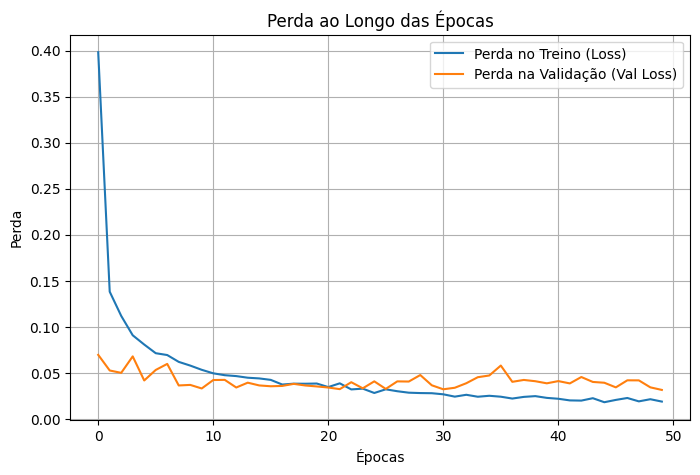

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(historico.history['loss'], label='Perda no Treino (Loss)')
plt.plot(historico.history['val_loss'], label='Perda na Validação (Val Loss)')
plt.title('Perda ao Longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()
plt.grid(True)
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


<Figure size 1000x1000 with 0 Axes>

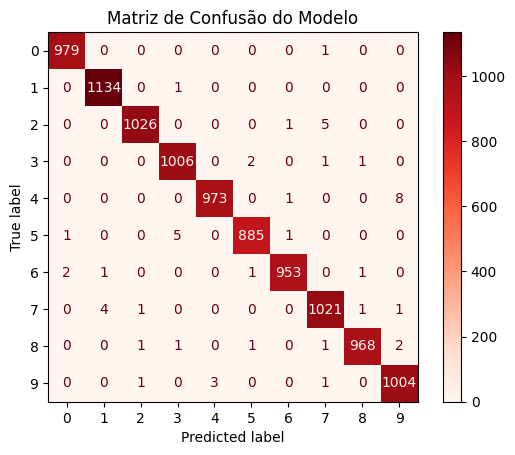

In [14]:
previsoes_prob = modelo.predict(test_X)
previsoes_classes = np.argmax(previsoes_prob, axis=1)

y_verdadeiro = test_Y
cm = confusion_matrix(y_verdadeiro, previsoes_classes)

plt.figure(figsize=(10, 10))

cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
cmd.plot(cmap=plt.cm.Reds, values_format='d')

plt.title('Matriz de Confusão do Modelo')
plt.show()

# Etapa 3
# Teste real com variáveis de fora do dataset.


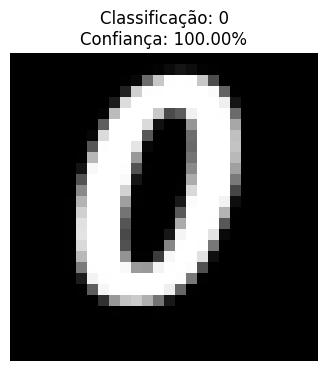

Probabilidades por classe:
Dígito 0: 100.00%
Dígito 1: 0.00%
Dígito 2: 0.00%
Dígito 3: 0.00%
Dígito 4: 0.00%
Dígito 5: 0.00%
Dígito 6: 0.00%
Dígito 7: 0.00%
Dígito 8: 0.00%
Dígito 9: 0.00%


In [23]:
import cv2

def prever_numero(caminho_da_imagem):
    img = cv2.imread(caminho_da_imagem, cv2.IMREAD_GRAYSCALE)

    img_resized = cv2.resize(img, (28, 28), interpolation=cv2.INTER_AREA)
    img_inverted = cv2.bitwise_not(img_resized)
    img_normalized = img_inverted.astype('float32') / 255.0
    img_final = img_normalized.reshape(1, 28, 28, 1)

    predicao = modelo.predict(img_final, verbose=0)
    classe = np.argmax(predicao)

    plt.figure(figsize=(4,4))
    plt.imshow(img_inverted, cmap='gray')
    plt.title(
        f"Classificação: {classe}\n"
        f"Confiança: {predicao[0][classe]*100:.2f}%"
    )
    plt.axis('off')
    plt.show()

    print("Probabilidades por classe:")
    for i, prob in enumerate(predicao[0]):
        print(f"Dígito {i}: {prob*100:.2f}%")

prever_numero('/content/numero.jfif')